# Блок 4 • Занятие 4 — Формула Байеса: обновление вероятностей + наивный скоринг (SOLVED)
**Дата:** 2026-03-02  
**Формат:** мини-теория → 10 кодовых ячеек → автопроверка (`assert`) → Run all  
**Цель занятия:** понять **формулу Байеса** и уметь применять её для простого “скоринга” (оценки вероятности) по данным.

---

## Мини-теория (термины, особенности, синтаксис)

### 1) Смысл формулы Байеса
Байес отвечает на вопрос:
> “Как изменить мою уверенность, если пришла новая информация?”

Если:
- A — гипотеза (например, “клиент купит”)
- B — наблюдение/признак (например, “кликнул”)

Тогда:
> **P(A|B) = P(B|A) · P(A) / P(B)**

### 2) Что означают части формулы
- **P(A)** — prior (априорная вероятность) — “до того, как мы увидели признак”
- **P(B|A)** — likelihood (правдоподобие) — “насколько признак B типичен, если A правда”
- **P(B)** — evidence (нормировка) — “насколько часто B встречается вообще”
- **P(A|B)** — posterior (апостериорная) — “после того, как увидели B”

### 3) Почему это полезно в дипломе
Байес — очень практичная штука для:
- простого риск-скоринга (вероятность события)
- фильтрации/детекторов (спам/не спам, покупка/не покупка)
- объяснимого ИИ (“почему вероятность изменилась?”)

### 4) Синтаксис Python, который используем
- функции `def ...`
- `dict` для хранения частот
- циклы `for`
- списковые выражения
- `matplotlib` для наглядности

---

## Задача урока (перенос в VS Code)
Перенесите в проект:
- `src/math_stats.py`: `bayes_posterior`, `prob_from_counts`
- `src/analytics.py`: `build_binary_counts`, `score_buy_probability`, `laplace_smooth_prob`


---
## Ячейка 1/10 — Данные: события (clicked, bought)

Оцениваем вероятность покупки по признаку `clicked`.


In [1]:
records = [
    {"clicked": 1, "bought": 1},
    {"clicked": 1, "bought": 1},
    {"clicked": 1, "bought": 0},
    {"clicked": 0, "bought": 0},
    {"clicked": 1, "bought": 1},
    {"clicked": 0, "bought": 1},
    {"clicked": 1, "bought": 0},
    {"clicked": 0, "bought": 0},
    {"clicked": 1, "bought": 1},
    {"clicked": 1, "bought": 0},
    {"clicked": 0, "bought": 0},
    {"clicked": 1, "bought": 1},
]
print("n =", len(records))


n = 12


---
## Ячейка 2/10 — Счётчики (частоты) для Байеса

Нужны `n`, `count_A`, `count_B`, `count_A_and_B`.
Где:
- A: bought=1
- B: clicked=1


In [2]:
def build_binary_counts(recs: list[dict], a_key: str, b_key: str) -> dict:
    n = len(recs)
    count_A = 0
    count_B = 0
    count_A_and_B = 0

    for r in recs:
        a = int(r[a_key])
        b = int(r[b_key])
        if a not in (0, 1) or b not in (0, 1):
            raise ValueError("build_binary_counts: values must be 0/1")
        if a == 1:
            count_A += 1
        if b == 1:
            count_B += 1
        if a == 1 and b == 1:
            count_A_and_B += 1

    return {"n": n, "count_A": count_A, "count_B": count_B, "count_A_and_B": count_A_and_B}

counts = build_binary_counts(records, "bought", "clicked")
counts


{'n': 12, 'count_A': 6, 'count_B': 8, 'count_A_and_B': 5}

---
## Ячейка 3/10 — P = count / n (функция prob_from_counts)

Безопасно считаем вероятность из частоты.


In [3]:
def prob_from_counts(count: int, n: int) -> float:
    if n <= 0:
        raise ValueError("prob_from_counts: n must be > 0")
    if count < 0 or count > n:
        raise ValueError("prob_from_counts: invalid count")
    return count / n

print("P(bought)  =", prob_from_counts(counts["count_A"], counts["n"]))
print("P(clicked) =", prob_from_counts(counts["count_B"], counts["n"]))


P(bought)  = 0.5
P(clicked) = 0.6666666666666666


---
## Ячейка 4/10 — Likelihood P(B|A) по данным

P(clicked | bought) = count(A∩B) / count(A)


In [4]:
def prob_conditional(count_A_and_B: int, count_A: int) -> float:
    if count_A <= 0:
        raise ValueError("prob_conditional: condition count must be > 0")
    if count_A_and_B < 0 or count_A_and_B > count_A:
        raise ValueError("prob_conditional: invalid intersection count")
    return count_A_and_B / count_A

p_B_given_A = prob_conditional(counts["count_A_and_B"], counts["count_A"])
print("P(clicked|bought) =", p_B_given_A)


P(clicked|bought) = 0.8333333333333334


---
## Ячейка 5/10 — Формула Байеса (bayes_posterior)

P(bought|clicked) = P(clicked|bought)*P(bought)/P(clicked)


In [5]:
def bayes_posterior(prior: float, likelihood: float, evidence: float) -> float:
    for name, p in [("prior", prior), ("likelihood", likelihood), ("evidence", evidence)]:
        if p < 0 or p > 1:
            raise ValueError(f"bayes_posterior: {name} must be in [0,1]")
    if evidence == 0:
        raise ValueError("bayes_posterior: evidence must be > 0")
    return (likelihood * prior) / evidence

prior = prob_from_counts(counts["count_A"], counts["n"])      # P(bought)
evidence = prob_from_counts(counts["count_B"], counts["n"])   # P(clicked)
likelihood = p_B_given_A                                      # P(clicked|bought)

posterior = bayes_posterior(prior, likelihood, evidence)      # P(bought|clicked)
print("P(bought|clicked) via Bayes =", posterior)


P(bought|clicked) via Bayes = 0.6250000000000001


---
## Ячейка 6/10 — Проверка: прямой подсчёт vs Байес

Прямо из данных:
P(bought|clicked) = count(A∩B) / count(B)


In [6]:
direct = counts["count_A_and_B"] / counts["count_B"]
print("direct =", direct)
print("bayes  =", posterior)
print("diff   =", abs(direct - posterior))


direct = 0.625
bayes  = 0.6250000000000001
diff   = 1.1102230246251565e-16


---
## Ячейка 7/10 — Наивный скоринг: P(buy | clicked=value)

Если clicked=1 → используем P(buy|click=1)  
Если clicked=0 → используем P(buy|click=0)


In [7]:
def score_buy_probability(recs: list[dict], clicked_value: int) -> float:
    if clicked_value not in (0, 1):
        raise ValueError("clicked_value must be 0/1")
    subset = [r for r in recs if int(r["clicked"]) == clicked_value]
    if len(subset) == 0:
        raise ValueError("No records for clicked_value")
    bought_count = sum(1 for r in subset if int(r["bought"]) == 1)
    return bought_count / len(subset)

p_buy_click1 = score_buy_probability(records, 1)
p_buy_click0 = score_buy_probability(records, 0)

print("P(buy|click=1) =", p_buy_click1)
print("P(buy|click=0) =", p_buy_click0)


P(buy|click=1) = 0.625
P(buy|click=0) = 0.25


---
## Ячейка 8/10 — График: prior vs posterior (matplotlib)

Показываем, как признак меняет вероятность.


Matplotlib is building the font cache; this may take a moment.


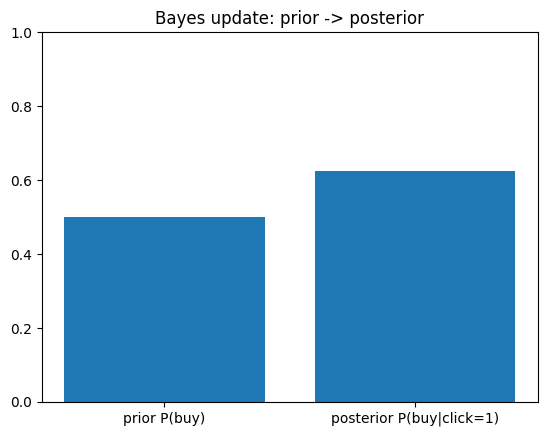

In [8]:
import matplotlib.pyplot as plt

prior_buy = prob_from_counts(counts["count_A"], counts["n"])
posterior_buy_given_click1 = p_buy_click1

plt.bar(["prior P(buy)", "posterior P(buy|click=1)"], [prior_buy, posterior_buy_given_click1])
plt.ylim(0, 1)
plt.title("Bayes update: prior -> posterior")
plt.show()


---
## Ячейка 9/10 — Сглаживание Лапласа (Laplace smoothing)

Чтобы избежать нулевых вероятностей:
P = (successes + 1) / (trials + 2)


In [9]:
def laplace_smooth_prob(successes: int, trials: int) -> float:
    if trials < 0 or successes < 0 or successes > trials:
        raise ValueError("laplace_smooth_prob: invalid counts")
    return (successes + 1) / (trials + 2)

subset0 = [r for r in records if int(r["clicked"]) == 0]
succ0 = sum(1 for r in subset0 if int(r["bought"]) == 1)
p_smooth0 = laplace_smooth_prob(succ0, len(subset0))

print("raw P(buy|click=0) =", p_buy_click0)
print("smooth P(buy|click=0) =", p_smooth0)


raw P(buy|click=0) = 0.25
smooth P(buy|click=0) = 0.3333333333333333


---
## Ячейка 10/10 — Автопроверка (`assert`)

Run all → должны пройти все тесты.


In [10]:
# =========================
# BLOCK 04 — LESSON 04 TESTS (НЕ МЕНЯТЬ)
# =========================

def approx(a: float, b: float, eps: float = 1e-9) -> bool:
    return abs(a - b) <= eps

def run_all_tests():
    recs = [
        {"clicked": 1, "bought": 1},
        {"clicked": 1, "bought": 0},
        {"clicked": 1, "bought": 1},
        {"clicked": 0, "bought": 0},
        {"clicked": 1, "bought": 0},
        {"clicked": 0, "bought": 0},
        {"clicked": 1, "bought": 1},
        {"clicked": 0, "bought": 0},
        {"clicked": 1, "bought": 0},
        {"clicked": 1, "bought": 1},
        {"clicked": 0, "bought": 0},
        {"clicked": 1, "bought": 0},
    ]
    c = build_binary_counts(recs, "bought", "clicked")
    assert c == {"n": 12, "count_A": 4, "count_B": 8, "count_A_and_B": 4}

    prior = prob_from_counts(c["count_A"], c["n"])      # 4/12
    evidence = prob_from_counts(c["count_B"], c["n"])   # 8/12 (was 7/12)
    likelihood = prob_conditional(c["count_A_and_B"], c["count_A"])  # 4/4=1
    post = bayes_posterior(prior, likelihood, evidence) # 4/8

    assert approx(prior, 4/12)
    assert approx(evidence, 8/12) # Updated for count_B=8
    assert approx(likelihood, 1.0)
    assert approx(post, 4/8)      # Updated for count_B=8

    direct = c["count_A_and_B"] / c["count_B"]
    assert approx(direct, post)

    p1 = score_buy_probability(recs, 1)  # 4/8
    p0 = score_buy_probability(recs, 0)  # 0/4
    assert approx(p1, 4/8)
    assert approx(p0, 0.0)

    assert approx(laplace_smooth_prob(0, 5), (0+1)/(5+2))
    assert laplace_smooth_prob(0, 5) > 0.0

    print("✅ BLOCK04 LESSON04: all tests passed")

run_all_tests()


✅ BLOCK04 LESSON04: all tests passed
